# Autoencoders

## Loading and splitting the data

In [38]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

olivetti_faces = fetch_olivetti_faces()
X = olivetti_faces.images
y = olivetti_faces.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=86)

#reshape
X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 360
Test set size: 40


In [39]:
# perform pca on the training set for feature extraction
from sklearn.decomposition import PCA
import numpy as np

X_train_flattened = X_train.reshape(X_train.shape[0], -1)

pca = PCA(n_components=0.99)
pca.fit(X_train_flattened)

X_train_pca = pca.transform(X_train_flattened)
print(f"Number of components: {pca.n_components_}")

Number of components: 240


## Defining the autoencoder

In [44]:
from keras import layers, regularizers, models, optimizers
from sklearn.model_selection import KFold

def build_autoencoder(input_dim, hidden_units=128, learning_rate=0.001, regularizer_strength=0.01):
    encoding_dim = 32
    # Encoder
    input_layer = layers.Input(shape=(input_dim,))
    x = layers.Dense(hidden_units, activation='relu', 
                     kernel_regularizer=regularizers.l2(regularizer_strength))(input_layer)
    
    # Latent space 
    latent_space = layers.Dense(encoding_dim, activation='relu')(x)
    
    # Decoder
    x = layers.Dense(hidden_units, activation='relu')(latent_space)
    output_layer = layers.Dense(4096, activation='sigmoid')(x) # Sigmoid activation for pixel values between 0 and 1
    
    # Model definition
    autoencoder = models.Model(input_layer, output_layer)
    autoencoder.compile(optimizer=optimizers.Adam(learning_rate=learning_rate),
                        loss='mean_squared_error')
    return autoencoder

# K-Fold Cross-Validation setup
kf = KFold(n_splits=3, shuffle=True, random_state=86)

# Hyperparameter tuning via K-Fold Cross-Validation
best_model = None
best_val_loss = float('inf')

learning_rates = [0.1, 0.01, 0.001, 0.0001]
hidden_units_values = [64, 128, 200] 
regularizer_strengths = [0.1, 0.01, 0.001, 0.0001]

# Perform k-fold cross-validation
for learning_rate in learning_rates:
    for hidden_units in hidden_units_values:
        for reg_strength in regularizer_strengths:
            fold_val_losses = []
            
            for train_idx, val_idx in kf.split(X_train):
                X_train_fold, X_val_fold = X_train_pca[train_idx], X_train_pca[val_idx]
                train_target, val_target = X_train[train_idx], X_train[val_idx]
                # Build and train model
                model = build_autoencoder(pca.n_components_,
                                          hidden_units=hidden_units,
                                          learning_rate=learning_rate,
                                          regularizer_strength=reg_strength)
                
                model.fit(X_train_fold, train_target, epochs=20, batch_size=8, validation_data=(X_val_fold, val_target))
                
                # Evaluate on validation set
                val_loss = model.evaluate(X_val_fold, val_target)
                fold_val_losses.append(val_loss)
            
            avg_val_loss = np.mean(fold_val_losses)
            
            # Save the best model
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_model = model

print("Best model found!")

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.3821 - val_loss: 0.2035
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1258 - val_loss: 0.0299
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0241 - val_loss: 0.0203
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0199 - val_loss: 0.0199
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0203 - val_loss: 0.0200
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0206 - val_loss: 0.0198
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0202 - val_loss: 0.0202
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0192 - val_loss: 0.0199
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0194 - val_loss: 0.0201
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0199 - val_loss: 0.0201
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0195 - val_loss: 0.0200
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0193 - val_lo

In [45]:
best_model.summary()
best_val_loss

Model: "functional_287"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_287 (InputLayer)    │ (None, 240)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1148 (Dense)              │ (None, 200)            │        48,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1149 (Dense)              │ (None, 32)             │         6,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1150 (Dense)              │ (None, 200)            │         6,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1151 (Dense)              │ (None, 4096)           │       823,296 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,653,586 (10.12 MB)

 Trainable params: 884,528 (3.37 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,769,058 (6.75 MB)

0.006108277942985296

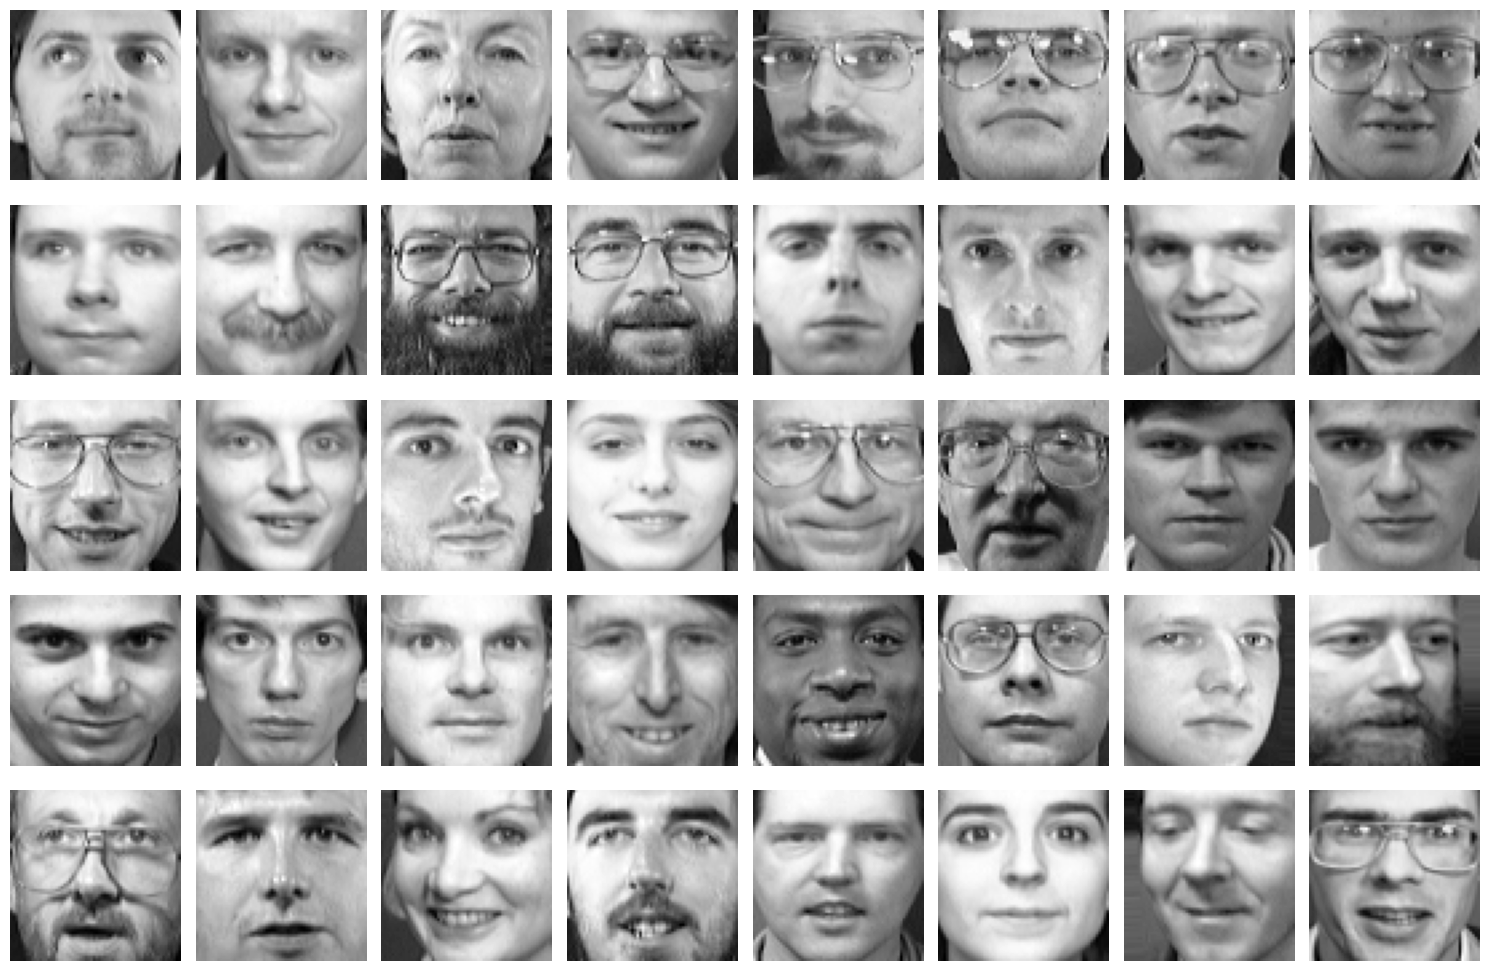

In [42]:
import matplotlib.pyplot as plt

# Plot all the 40 photos from the test set
fig, axes = plt.subplots(5, 8, figsize=(15, 10))
axes = axes.ravel()

for i in range(40):
    axes[i].imshow(X_test[i].reshape(64, 64), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Reconstructed Photos

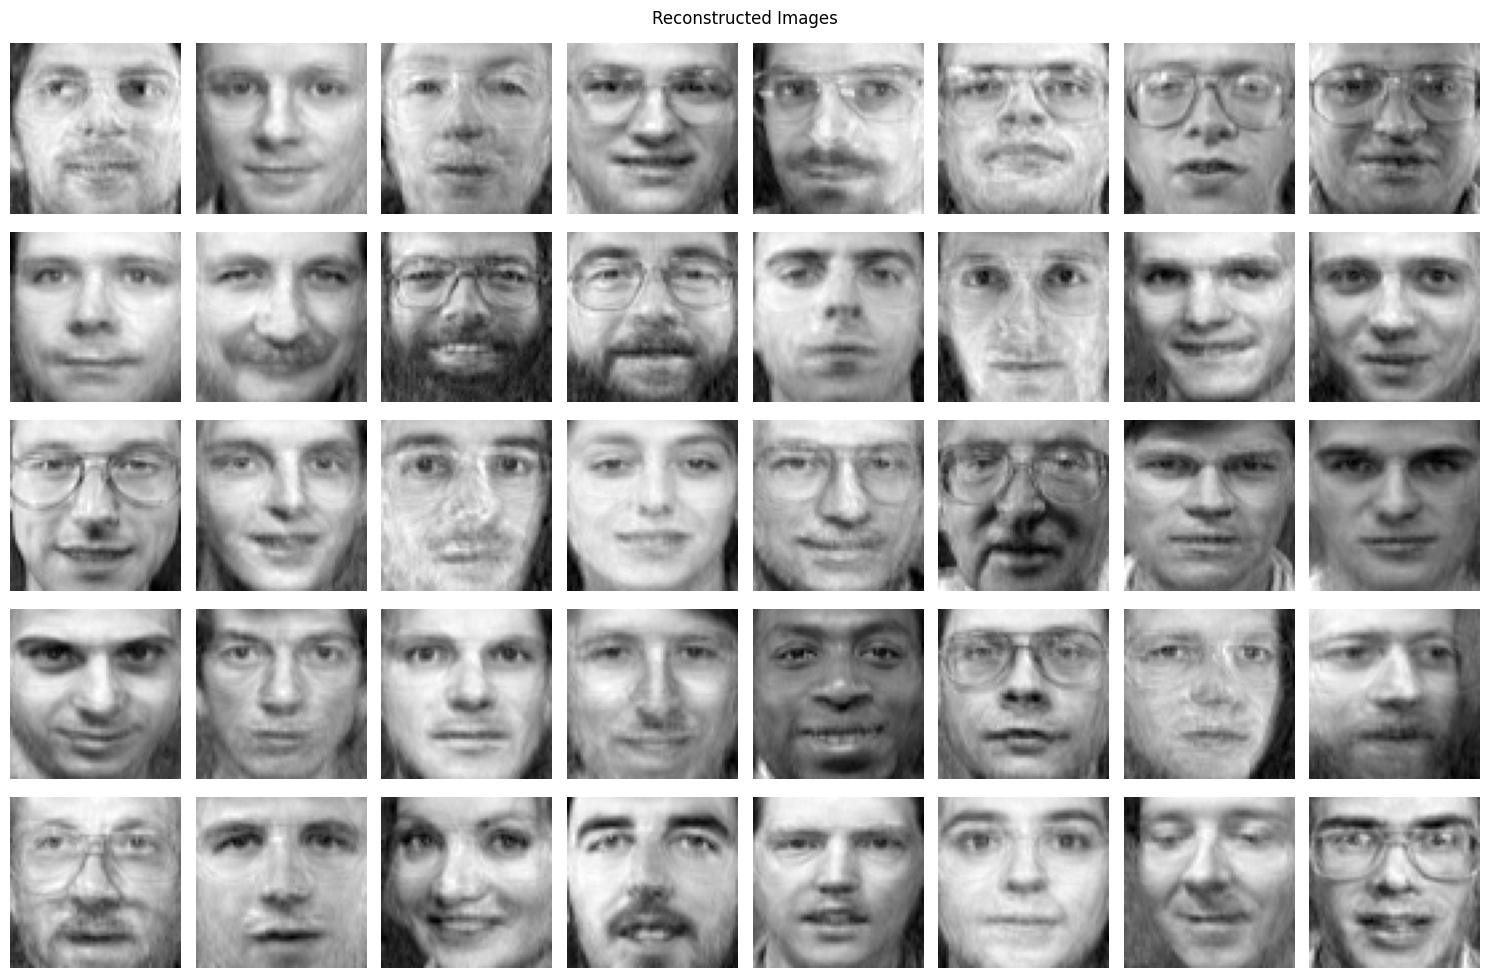

In [43]:
# Run the test images through the best model to get the reconstructed images
reconstructed_images = pca.inverse_transform(pca.transform(X_test))

fig, axes = plt.subplots(5, 8, figsize=(15, 10))
axes = axes.ravel()

for i in range(40):
    # Reconstructed image
    axes[i].imshow(reconstructed_images[i].reshape(64, 64), cmap='gray')
    axes[i].axis('off')

plt.suptitle('Reconstructed Images')
plt.tight_layout()
plt.show()